<div class="alert alert-block alert-success">
    
# Case Study 📓: Predicting Conversion Rate
    
#### [**Case Study Link**](https://docs.google.com/document/d/1pt2PxePa2uLJOvgrveAF9L_mlabb6wHOs2xawqcBdK8/edit?usp=sharing)


 👨‍🏫 **Vikesh K**      



</div>

<div class="alert alert-block alert-danger">
    
# OH Agenda 📝
    
We will cover:

* ML Overview
* Conversion Case Study
    * EDA with respect to model building
    * Data Prep
    * Model Building
    * Business Insights
    
    
 </div>

##  <font color= darkred> Import modules and data </font>

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# data viz
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# plt.style.use("fivethirtyeight") # styling the charts

**Load Data**

In [2]:
url = 'https://raw.githubusercontent.com/vkoul/data/main/misc/conversion_data.csv'

df = pd.read_csv(url)

In [3]:
df.sample(10)

,country,age,new_user,source,total_pages_visited,converted
20166,US,33,1,Direct,1,0
288963,China,29,1,Ads,3,0
48564,US,26,1,Direct,6,0
150499,US,49,1,Seo,1,0
73473,Germany,24,1,Direct,1,0
37770,US,34,0,Ads,2,0
132442,US,25,1,Seo,1,0
215332,China,19,1,Direct,7,0
261347,US,32,0,Direct,3,0
66526,US,29,0,Seo,2,0


## Hypothesis


* **Data Quality**
  * Missing values
  * data types- if they are correct
  * duplicates
  * outliers

* **Exploration**
  * Univariate
    * kde, histogram
    * boxplots
    * bar charts
  * Bivariate analysis
    * scatter
    * bar chart
    * ratios
    * correlation for numeric

* **Pre-processing: before the modeling**
  * Imputation
  * Encoding - One Hot
  * Numerical - Standardisation

* **Modeling**

  * Knn- classification
  * Logistic Regression
  * Decision Trees Classifier
  * Random Forest Classifier


##  <font color= darkred> Data Inspection</font>🔍📊

### <font color= darkred> Numerical inspection and summaries </font>

**Data Inspect**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316200 entries, 0 to 316199
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              316200 non-null  object
 1   age                  316200 non-null  int64 
 2   new_user             316200 non-null  int64 
 3   source               316200 non-null  object
 4   total_pages_visited  316200 non-null  int64 
 5   converted            316200 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 14.5+ MB


**Missing values check**

In [5]:
df.isna().sum()

,0
country,0
age,0
new_user,0
source,0
total_pages_visited,0
converted,0


**Duplicates**

In [6]:
df.duplicated().sum()

np.int64(299903)

In [7]:
# df[df.duplicated()].sort_values(by = ["country", "age", "total_pages_visited"]).head(10)

In [8]:
df = df.drop_duplicates().copy()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(16297, 6)

##   <font color= darkred> EDA </font>

### Univariate Analysis

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16297 entries, 0 to 316098
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   country              16297 non-null  object
 1   age                  16297 non-null  int64 
 2   new_user             16297 non-null  int64 
 3   source               16297 non-null  object
 4   total_pages_visited  16297 non-null  int64 
 5   converted            16297 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 891.2+ KB


In [12]:
df.head(3)

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0


**Pie Chart**

In [13]:
df["converted"].value_counts()

,count
converted,
0,11969
1,4328


In [14]:
df["converted"].value_counts(normalize = True).round(2)

,proportion
converted,
0,0.73
1,0.27


In [15]:
df["converted"].mean().round(2)

np.float64(0.27)

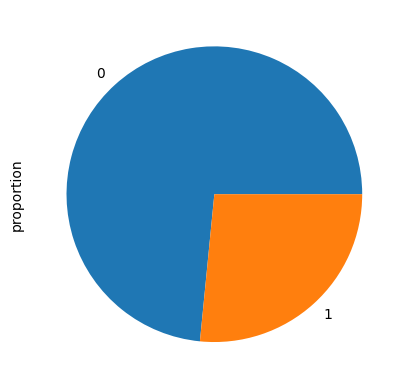

In [16]:
df["converted"].value_counts(normalize = True).plot(kind = "pie");

In [17]:
df.describe().round(2)

,age,new_user,total_pages_visited,converted
count,16297.00,16297.0,16297.00,16297.00
mean,33.85,0.5,9.00,0.27
std,11.46,0.5,5.42,0.44
min,17.00,0.0,1.00,0.00
25%,24.00,0.0,5.00,0.00
50%,32.00,1.0,9.00,0.00
75%,42.00,1.0,13.00,1.00
max,123.00,1.0,29.00,1.00


In [18]:
df.describe([0.85, 0.95, 0.99]).round(2) # pecrcentiles

,age,new_user,total_pages_visited,converted
count,16297.00,16297.0,16297.00,16297.00
mean,33.85,0.5,9.00,0.27
std,11.46,0.5,5.42,0.44
min,17.00,0.0,1.00,0.00
50%,32.00,1.0,9.00,0.00
85%,47.00,1.0,15.00,1.00
95%,55.00,1.0,19.00,1.00
99%,61.00,1.0,23.00,1.00
max,123.00,1.0,29.00,1.00


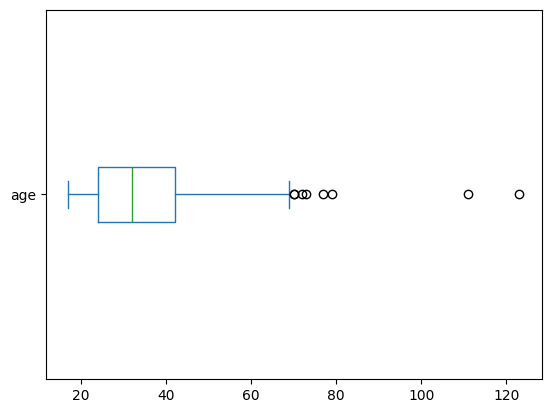

In [19]:
df["age"].plot(kind = "box", vert = False);

In [20]:
df = df.query("age < 80").copy()

In [21]:
df.shape

(16295, 6)

<Figure size 1000x500 with 0 Axes>

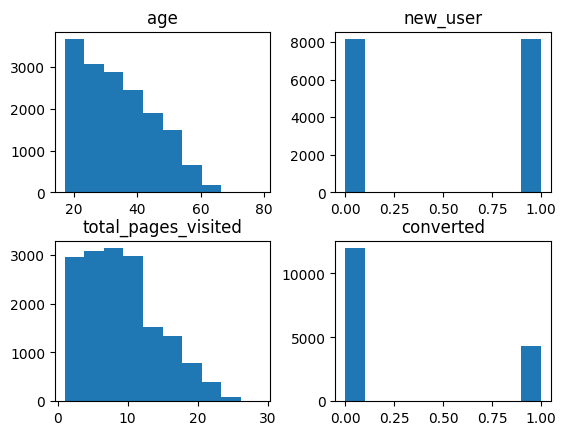

In [22]:
plt.figure(figsize = (10, 5));
df.hist(grid = False);

In [23]:
df.describe(include = "object")

,country,source
count,16295,16295
unique,4,3
top,US,Seo
freq,5814,6091


### Bivariate Analysis

In [24]:
# df.groupby("source").describe().T.round(2)

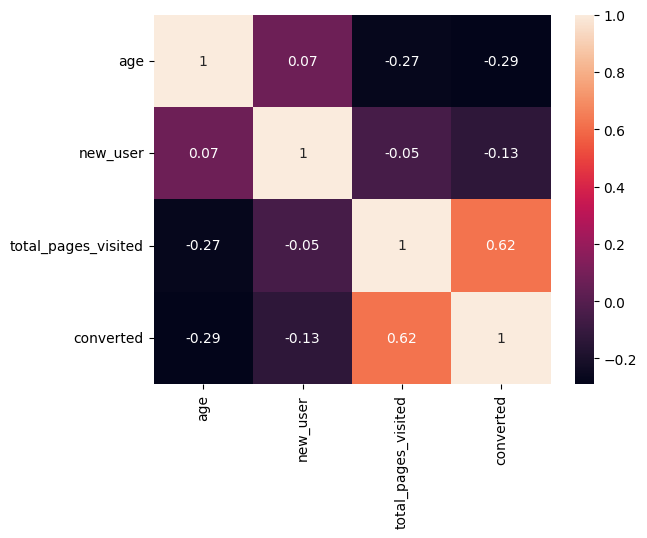

In [25]:
corr = df.corr(numeric_only = True).round(2)

sns.heatmap(corr, annot = True);

In [26]:
# df.groupby("country").corr(numeric_only = True).round(2)

**Categorical Values**

In [27]:
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


In [28]:
cat_cols = df.select_dtypes("object").columns.tolist()
cat_cols

['country', 'source']

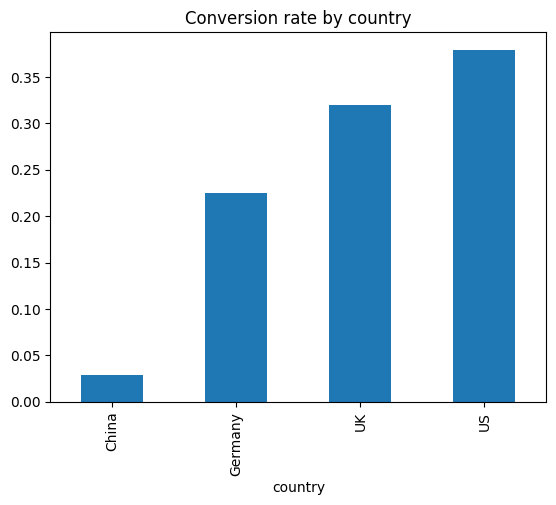

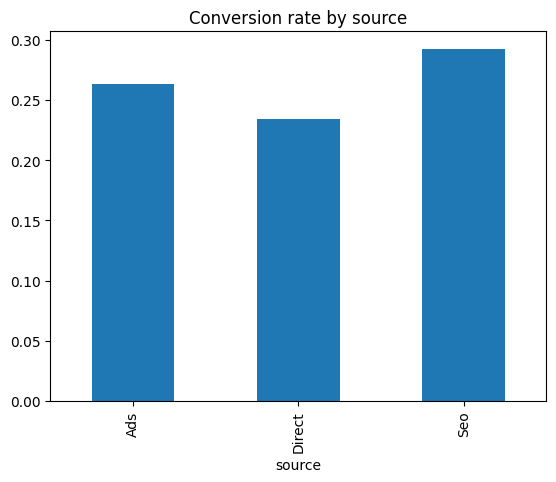

In [29]:
for cat in cat_cols:
    df.groupby(cat)["converted"].mean().plot(kind = "bar", title = f"Conversion rate by {cat}");
    plt.show();

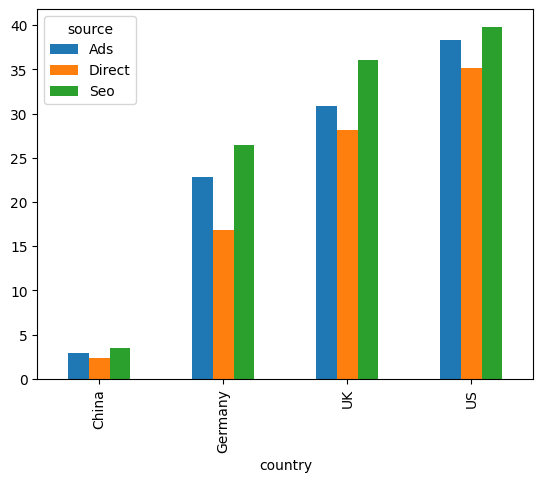

In [30]:
 df.groupby(["country", "source"])["converted"].mean().multiply(100).unstack().plot(kind = 'bar');

In [31]:
 df.groupby('source')["converted"].mean().multiply(100).round(2)

,converted
source,
Ads,26.36
Direct,23.41
Seo,29.24


In [32]:
df.groupby('total_pages_visited')['converted'].mean().multiply(100).plot(kind = 'line', backend = 'plotly')

In [33]:
df.groupby('age')['converted'].mean().multiply(100).plot(kind = 'line', backend = 'plotly')

<div class="alert alert-block alert-success">

# Reference material 📚


* [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/): good book for hands on practice and codes.
* [ISLR](https://www.statlearning.com/)- covers theory nicely
    
</div>